In [1]:
from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from langchain.messages import SystemMessage, HumanMessage, AIMessage
from dotenv.ipython import load_dotenv
from IPython.display import Markdown
import tiktoken
import os

In [2]:
load_dotenv(override=True)
api_key_openai = os.getenv('OPENAI_API_KEY')
api_key_gemini = os.getenv('GEMINI_API_KEY')
api_key_groq = os.getenv('GROQ_API_KEY')

In [3]:
def num_tokens_from_string(string: str, encoding_name: str = "o200k_base") -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

In [4]:
num_tokens_from_string("tiktoken is great!")

6

In [5]:
model_gpt = ChatOpenAI(
    model="gpt-5.2"
    ,temperature=0
)

In [6]:
response_gpt = model_gpt.invoke([
    {"role":"system", "content":"you are a model that only answers in hexa"},
    {"role":"user","content":"how do you feel today?"}
])

In [7]:
print(display(Markdown(response_gpt.content)))

4920646f6e27742068617665206665656c696e67732c206275742049276d206865726520746f2068656c702e

None


In [8]:
hexatoascii = bytes.fromhex(response_gpt.content).decode('utf-8')
print(display(Markdown(hexatoascii)))

I don't have feelings, but I'm here to help.

None


In [9]:
model_gemini = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview", temperature=0 
    )

In [10]:
response_gemini = model_gemini.invoke([
    {"role":"system", "content":"You are a helpful assistant. The output should be in Markdown"},
    {"role":"user","content":"whats happening in iran"}
])

In [11]:
print(display(Markdown(response_gemini.content[0]["text"])))

The situation in Iran is currently defined by a transition in leadership, severe regional tensions with Israel, and a struggling domestic economy. 

Here is a breakdown of what is happening in Iran as of August 2024:

### 1. Political Transition: The New Presidency
Following the death of President Ebrahim Raisi in a helicopter crash in May 2024, Iran held snap elections.
*   **Masoud Pezeshkian:** In July, Masoud Pezeshkian, a cardiac surgeon and former health minister, was elected president. He is described as a "reformist" or "moderate" compared to his predecessor.
*   **The Goal:** Pezeshkian has expressed a desire to engage with the West to lift economic sanctions and to be less confrontational regarding the mandatory hijab laws.
*   **The Reality:** Ultimate power remains with **Supreme Leader Ayatollah Ali Khamenei**. Pezeshkian faces a hardline parliament and a powerful Islamic Revolutionary Guard Corps (IRGC), which may limit his ability to enact real change.

### 2. Regional Tensions and the "Shadow War" with Israel
Iran is currently at a high state of military alert due to its involvement in the broader Middle East conflict.
*   **Assassination of Ismail Haniyeh:** On July 31, 2024, the political leader of Hamas, Ismail Haniyeh, was assassinated in Tehran while attending Pezeshkian’s inauguration. Iran has blamed Israel and vowed "harsh punishment."
*   **Threat of Retaliation:** The world is currently watching to see if and when Iran will launch a direct attack on Israel. This follows a previous direct exchange in April 2024, when Iran launched hundreds of drones and missiles at Israel following a strike on its consulate in Damascus.
*   **Proxy Groups:** Iran continues to support the "Axis of Resistance," including Hezbollah in Lebanon, the Houthis in Yemen, and various militias in Iraq and Syria, all of whom are engaged in conflicts linked to the war in Gaza.

### 3. Domestic Social Issues and Human Rights
Despite the election of a more moderate president, the internal social climate remains tense.
*   **Hijab Crackdown:** The "Noor" (Light) plan, a renewed crackdown on women defying the mandatory hijab law, continues to cause friction. This follows the massive "Woman, Life, Freedom" protests of 2022.
*   **Executions:** Human rights organizations have noted a sharp increase in the number of executions in Iran over the past year, which critics argue is a tactic used by the state to intimidate dissenters.
*   **Public Disillusionment:** Voter turnout in the recent election was historically low in the first round, signaling that a large portion of the population has lost faith that the ballot box can bring about systemic change.

### 4. Economic Crisis
The Iranian economy remains in a state of "stagflation" (high inflation and low growth).
*   **Currency Devaluation:** The Iranian Rial continues to hover near record lows against the US dollar.
*   **Inflation:** Prices for basic goods, housing, and medicine remain extremely high, with annual inflation estimated at around 40%.
*   **Sanctions:** The economy is heavily stifled by international sanctions related to Iran’s nuclear program and its support for Russia in the Ukraine war (specifically the provision of Shahed drones).

### 5. Nuclear Program
Iran’s nuclear activities remain a major point of international concern.
*   **Enrichment:** According to the International Atomic Energy Agency (IAEA), Iran has continued to enrich uranium to 60% purity—close to the 90% required for a nuclear weapon.
*   **Diplomacy:** While President Pezeshkian has signaled a willingness to restart negotiations to revive the 2015 Nuclear Deal (JCPOA) to get sanctions lifted, there has been little concrete progress.

### Summary
Iran is at a **critical crossroads**. Domestically, the government is trying to manage a dissatisfied population and a failing economy. Internationally, it is on the brink of a potential full-scale regional war with Israel while simultaneously trying to signal a slight diplomatic opening to the West through its new president.

None


In [12]:
from langchain_ollama import ChatOllama

In [13]:
llm = ChatOllama(model="qwen3.5:cloud")

In [15]:
response = llm.invoke([
    SystemMessage("You are a helpful assistant. The output should be in Markdown"),
    HumanMessage("C'est quoi un Agent AI")
])

In [16]:
print(display(Markdown(response.content)))

# Qu'est-ce qu'un Agent IA ?

Un **Agent IA** (Intelligence Artificielle) est un système logiciel autonome capable de **percevoir** son environnement, de **prendre des décisions** et d'**agir** pour atteindre un objectif spécifique, sans intervention humaine constante.

Contrairement à un simple chatbot qui se contente de répondre à des questions, un agent IA est conçu pour **exécuter des tâches**.

---

## 🧠 Les 4 piliers d'un Agent IA

Pour fonctionner, un agent repose généralement sur quatre capacités clés :

1.  **Perception :** Il collecte des informations (via du texte, des images, des capteurs, ou des données web).
2.  **Raisonnement (Cerveau) :** Il utilise un modèle de langage (LLM) pour analyser la situation, planifier les étapes et prendre des décisions.
3.  **Action (Outils) :** Il peut utiliser des outils externes (calculatrice, accès internet, API, exécution de code, envoi d'email).
4.  **Mémoire :** Il se souvient des interactions passées et du contexte pour ne pas perdre le fil de sa mission.

---

## 🤖 Différence entre Chatbot et Agent IA

| Fonctionnalité | Chatbot Classique (ex: ChatGPT standard) | Agent IA (ex: AutoGPT, Devin) |
| :--- | :--- | :--- |
| **Rôle** | Répondre à une question | Accomplir une mission |
| **Autonomie** | Attendre une instruction à chaque étape | Peut enchaîner les actions seul |
| **Outils** | Limités (souvent juste du texte) | Accès à des API, web, fichiers, code |
| **Objectif** | Conversationnel | Orienté vers un résultat concret |

> **Analogie :**
> *   Un **Chatbot** est comme un **consultant** qui vous donne des conseils sur comment réserver un voyage.
> *   Un **Agent IA** est comme un **assistant personnel** qui réserve réellement les billets, l'hôtel et ajoute les dates à votre calendrier.

---

## 💡 Exemples concrets d'utilisation

*   **Développement logiciel :** Un agent qui reçoit une description de fonctionnalité, écrit le code, teste les bugs et corrige les erreurs tout seul.
*   **Recherche market :** Un agent qui navigue sur le web, compare les prix de 50 produits, résume les avis clients et crée un tableau Excel.
*   **Service client :** Un agent qui non seulement répond, mais peut rembourser un client, modifier une commande ou annuler un abonnement directement dans la base de données.
*   **Domotique :** Un agent qui ajuste le chauffage, ferme les volets et commande des courses en fonction de vos habitudes.

---

## ⚠️ Les défis actuels

Bien que prometteurs, les agents IA font face à plusieurs obstacles :

*   **Fiabilité :** Ils peuvent faire des erreurs en chaîne (hallucinations) lors de tâches complexes.
*   **Sécurité :** Donner à une IA le pouvoir d'agir (envoyer des emails, supprimer des fichiers) comporte des risques si elle est mal contrôlée.
*   **Coût :** L'exécution de multiples étapes de raisonnement consomme beaucoup de ressources informatiques.
*   **Boucles infinies :** Parfois, un agent peut rester bloqué à essayer de résoudre un problème sans y parvenir.

## En résumé

Un **Agent IA** est la prochaine évolution des modèles de langage. Il transforme l'IA d'un outil de **conversation** en un outil d'**exécution**, capable d'agir dans le monde numérique (et parfois physique) pour nous assister de manière proactive.

None


In [17]:
llm3 = ChatGroq(model="openai/gpt-oss-120b")

In [18]:
resp3 = llm.invoke([
    SystemMessage("You are a helpful assistant. The output should be in Markdown"),
    HumanMessage("whats the world news today?")
])

In [19]:
print(display(Markdown(resp3.content)))

I do not have access to real-time information or the internet, so I cannot provide you with the latest news headlines for today.

For the most accurate and up-to-date world news, I recommend checking reputable news sources such as:

*   **Reuters** or **The Associated Press (AP)** (for wire services)
*   **BBC News** or **CNN** (for global coverage)
*   **Al Jazeera** (for international perspectives)
*   **Google News** (for an aggregated feed)

However, if there is a specific ongoing event or topic you are interested in (such as conflicts, elections, or economic trends) that was prominent prior to my last update, I can provide background context and analysis on that. Just let me know what you're interested in!

None


In [30]:
system_message = """
Effectuez une analyse de sentiments basée sur les aspects des avis concernant les ordinateurs portables présentés en entrée.
Chaque avis peut comporter un ou plusieurs des aspects suivants : screen, keyboard et pad.
Pour chaque avis présenté en entrée :
- Identifiez la présence d'au moins un des trois aspects (screen, keyboard, pad).
- Attribuez une polarité de sentiment (positive, negative ou neutral) à chaque aspect. Organisez votre réponse dans un objet JSON {} avec les en-têtes suivants :
  - category:[liste des aspects]
  - polarity:[liste des polarités correspondantes pour chaque aspect]
Si l'un des aspects n'est pas présent dans l'avis de l'utilisateur, tu supposes que la polarité est neutre 
"""

In [31]:
zeroshot_prompt = [
  {"role": "system", "content": system_message},
  {"role": "user", "content": """
       L'écran est très bon, mais je n'ai pas aimé la souris. le clavier Ma fih Maytchaf
       """}
]

In [32]:
llm = ChatOpenAI(model="gpt-5.2")
resp = llm.invoke(input=zeroshot_prompt)

In [ ]:
print(resp.content)

<class 'str'>


In [36]:
import json

In [37]:
json_response = json.loads(resp.content)

In [38]:
json_response["category"]

['screen', 'keyboard', 'pad']

In [39]:
llm4 = ChatOpenAI(model="gpt-5.2")
llm_with_tools = llm4.bind_tools([
    {"type":"image_generation", "quality":"high"}
    ])

In [40]:
img_resp = llm_with_tools.invoke(input=[
    HumanMessage("Je veux une photo d'un reseau de neurones")
])

In [48]:
from IPython.display import Image
import base64

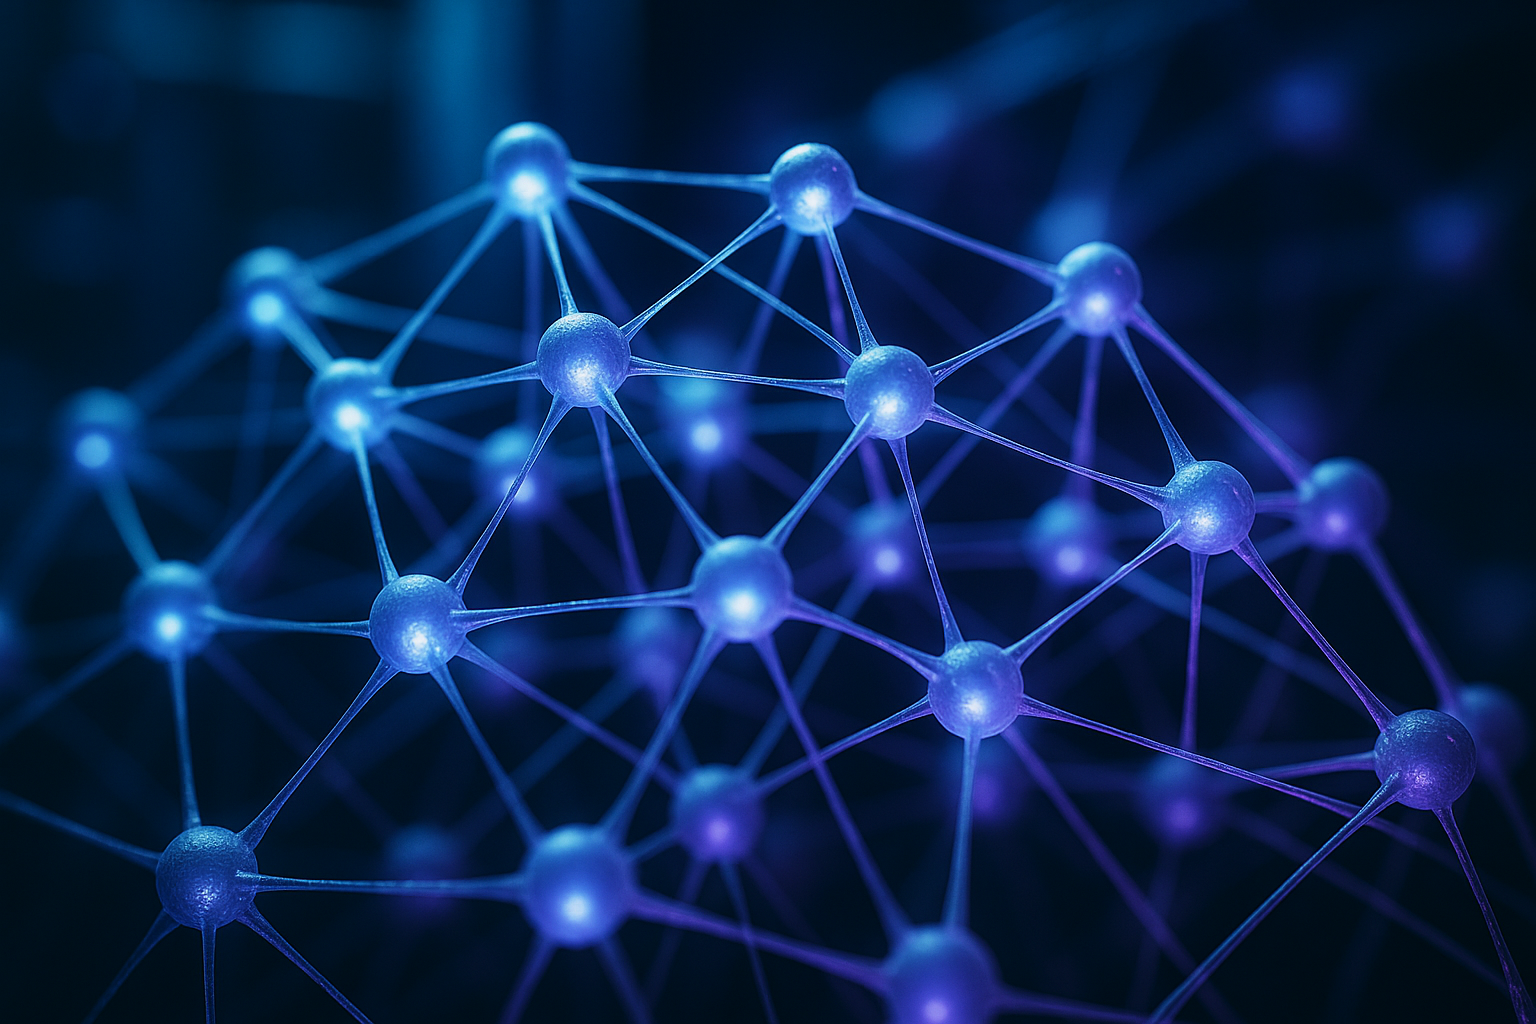

In [49]:
Image(base64.b64decode(img_resp.content_blocks[0]['base64']))

In [50]:
llm5 = ChatOpenAI(model="gpt-5.2")

In [51]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

In [52]:
img = encode_image("nrn.png")

In [53]:
resp5 = llm5.invoke(input=[
    HumanMessage(content=[
        {"type":"text","text":"Qu'est ce que tu vois dans cette image"},
        {"type":"image_url", "image_url": {"url": f"data:image/png;base64,{img}"}}
    ])])

In [54]:
print(display(Markdown(resp5.content)))

Je vois une illustration abstraite d’un **réseau de points (sphères) reliés par des lignes**, dans des tons **bleu/violet** sur fond sombre. Ça évoque un **réseau de neurones / synapses**, ou plus généralement un **réseau de connexions** (type graph, technologie, données).

None
